1 - Adicionar regret nos algoritimos (Bismark) []

2 - Adicionar seleção da quantidade de filtros por SVD [Bismark]; []

3 - Adicionar as explicações sobre VAW (Rickson); []

4 - Validar caso multivariável (Rickson); []

5 - Cleanup ()

# 1. Introduction and Motivation

## Spectral Filtering + VAW (Vovk-Azoury-Warmuth)

This notebook presents a practical implementation of **Spectral Filtering** combined with the **VAW (Vovk-Azoury-Warmuth)** online learning algorithm for sequential prediction in Linear Dynamical Systems (LDS).

The main objective is to investigate how temporal dynamics can be represented in a compact spectral basis using Hankel matrices and Singular Value Decomposition (SVD), while an online second-order learning algorithm adaptively estimates the system behavior over time.

In addition to the implementation of the online prediction framework, this notebook also explores the spectral geometry of different Hankel matrix constructions and analyzes how alternative kernel formulations affect the resulting spectral decomposition, spectral filters, and energy distribution across the dominant modes.

The notebook is organized into the following steps:

1. Simulation of Linear Dynamical Systems (LDS)
2. Construction of different Hankel matrix formulations
3. Spectral decomposition using Eigenvalue Decomposition (EVD) and Singular Value Decomposition (SVD)
4. Analysis of spectral geometry and spectral filters
5. Extraction of spectral features
6. Online learning using the VAW algorithm
7. Sequential prediction and performance evaluation

This implementation is inspired by modern approaches in:

- Online Control
- Online Convex Optimization
- Spectral Filtering
- Linear Dynamical Systems
- Adaptive Filtering
- Sequential Prediction

## Reference Algorithm
The methodology follows ideas presented in the literature on *Introduction to Online Control* (version 1.2 β) by Elad Hazan and Karan Singh. The analised Algorithm we that is refered to in the following sections, is presented below:

| **Algorithm 8** - Spectral Filtering with VAW |
|---|
| **1:**&emsp;Input: filter size $h$, regularization parameter $\lambda > 0$, horizon $T$.<br> **2:**&emsp;Precompute the top $h$ eigenvectors of $Z_T$, stored in $\Phi_h \in \mathbb{R}^{T\times h}$.<br> **3:**&emsp;Initialize the curvature matrix and target vector: $A_0 = \lambda I_h$, $v_0 = 0 \in \mathbb{R}^h$.<br><br> **4:**&emsp;**for** $t = 1,2,\dots,T$:<br>**5:**&emsp;&emsp;Construct the delayed input history: $\tilde u_t = [u_{t-1},u_{t-2},\dots,u_1,0,\dots,0]^\top$.<br> **6:**&emsp;&emsp;Project the delayed history onto the spectral basis: $h_t = \Phi_h^\top \tilde u_t$.<br> **7:**&emsp;&emsp;Update the curvature matrix: $A_t = A_{t-1} + h_t h_t^\top$.<br> **8:**&emsp;&emsp;Predict the output and observe the true response: $\hat y_t = h_t^\top A_t^{-1} v_{t-1}$.<br> **9:**&emsp;&emsp;Update the target accumulator vector: $v_t = v_{t-1} + y_t h_t$.<br> **10:**&emsp;**end for**. |


## 1.1 Importing Libraries and Premesis

We use:

- `NumPy` for numerical linear algebra;
- `Matplotlib` for visualization.

These libraries support the implementation of spectral decompositions, online learning updates, and visualization of the resulting temporal structures.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)


In the scope of this work the considered time horizon will be $T = 200$

In [2]:
T = 200

## 1.2 Linear Dynamical Systems

Linear Dynamical Systems (LDS) are mathematical models widely used to describe temporal processes whose future behavior depends on both the current state of the system and external inputs.

In control theory, signal processing, and sequential prediction, many physical and computational systems can be approximated using linear state-space representations. These models are particularly important because they provide a compact mathematical framework for representing temporal memory and dynamical evolution.

In this notebook, we consider a discrete-time Linear Time-Invariant (LTI) system defined by:

$$
\vec{x}_{k+1} = A\vec{x}_k + B\vec{u}_k + \vec{w}_k
$$

$$
\vec{y}_k = C\vec{x}_k
$$

where:

- $\vec{x}_k \in \mathbb{R}^n$ represents the hidden state of the system;
- $\vec{u}_k \in \mathbb{R}^q$ represents the input or control signal;
- $\vec{y}_k \in \mathbb{R}^r$ represents the observed output.
- $\vec{w}_k \in \mathbb{R}^n \sim \mathcal{N}(0,0.05)$ is additive process noise.

The matrices:

$$
A \in \mathbb{R}^{n\times n}
$$

$$
B \in \mathbb{R}^{n\times q}
$$

$$
C \in \mathbb{R}^{r\times n}
$$

define respectively:

- the internal system dynamics;
- how external inputs influence the hidden state;
- how the hidden state is mapped to the observable outputs.

A fundamental characteristic of linear dynamical systems is the existence of temporal memory. Future outputs depend recursively on previous states and inputs, creating strong temporal correlations across the trajectory of the system.

This temporal dependency is precisely what makes sequential prediction and online learning challenging. Instead of treating observations as independent samples, the learning algorithm must capture the underlying temporal structure governing the evolution of the system.

The goal of spectral filtering is to represent these temporal dependencies in a compact spectral form, allowing efficient learning and prediction of the system dynamics.

In this first part we will be considering a 1D LDS for simplicity, as defined below:

In [3]:
# Stable linear system
A = np.array([[0.95]])
B = np.array([[0.5]])
C = np.array([[1.0]])

def rollout(A, B, C, T, noise_std=0.5):
    n, _ = A.shape
    _, q = B.shape
    r, _ = C.shape

    x = np.zeros((T + 1, n))

    u = np.random.randn(T, q)

    y = np.zeros((T, r))

    for t in range(T):
        x[t + 1] = A @ x[t] + B @ u[t]

        if noise_std > 0:
            x[t + 1] += noise_std * np.random.randn(n)

        y[t] = C @ x[t]

    return x, u, y

## 2. Spectral Filtering and Temporal Representations

## 2.1 Why Spectral Filtering?

One of the main challenges in sequential prediction and online control is representing temporal dependencies efficiently.

Linear Dynamical Systems (LDS) possess memory because future outputs depend not only on the current input, but also on the accumulated effect of past states and inputs. As a consequence, learning and predicting temporal dynamics directly in the time domain may become computationally expensive and difficult to interpret.

Spectral filtering addresses this problem by transforming temporal dynamics into a spectral representation. Instead of modeling temporal dependencies directly in the original signal space, the dynamics are projected into a compact basis $\Phi$ composed of dominant spectral modes:

$$
\Phi
=
[\phi_1,\phi_2,\dots,\phi_h]
$$

where each:

$$
\phi_i \in \mathbb{R}^T
$$

corresponds to one of the dominant spectral filters, e.g. obtained from the decomposition of the Hankel matrix. The spectral filters act then as temporal basis functions that compress the temporal dynamics of the system into a representation suitable for online learning and sequential prediction.

This transformation is particularly useful because many dynamical systems exhibit low-dimensional temporal structures, meaning that a large portion of their behavior can often be represented using only a small number of dominant spectral components.

The objective of spectral filtering is therefore to extract the most relevant temporal structures while suppressing redundant or noisy components of the signal.

## 2.2 Hankel Matrices and Temporal Structure

A central object in spectral filtering and system identification is the Hankel matrix.

The Hankel matrix provides a structured representation of temporal dependencies by organizing sequential observations into overlapping temporal windows.

A Hankel matrix has the form:

$$
H_{ij} = h_{i+j}
$$

meaning that each anti-diagonal contains constant values.

Conceptually, the Hankel structure converts a one-dimensional temporal signal into a higher-dimensional representation where:

- rows represent temporal shifts;
- columns represent overlapping temporal segments.

This representation is particularly important because spectral methods operate more effectively on structured temporal representations than on raw sequential signals.

Linear dynamical systems naturally generate strong temporal correlations due to their internal memory structure. The Hankel matrix compactly organizes these correlations, allowing dominant temporal modes to emerge through spectral decompositions such as Eigenvalue Decomposition (EVD) and Singular Value Decomposition (SVD).

As a consequence, the spectral decomposition of Hankel matrices becomes closely related to the extraction of dominant dynamical patterns, temporal correlations, and low-dimensional structures present in the system trajectories.

## 2.3 Analytical Hankel Kernel

For the unidimensional case, the textbook leverages the properties of a structured matrix $Z_T$, which corresponds to a Hankel/Hilbert-type kernel constructed from monomial basis functions.

The matrix is defined as:

$$
Z_T
=
\int_0^1
\vec{\mu}_\alpha
\vec{\mu}_\alpha^T
\, d\alpha
$$

where $T$ is the time horizon and:

$$
\vec{\mu}_\alpha
=
(\alpha -1)
[1,\alpha,\alpha^2,\dots,\alpha^{T-1}]
\in \mathbb{R}^T
$$

The matrix $Z_T$ can be computed analytically. For each element:

$$
Z_T^{(i,j)}
=
\int_0^1
(\alpha-1)^2
\alpha^{i-1}
\alpha^{j-1}
\, d\alpha
$$

which yields:

$$
Z_T^{(i,j)}
=
\int_0^1
\alpha^{i+j}
-
2\alpha^{i+j-1}
+
\alpha^{i+j-2}
\, d\alpha
$$

resulting in the closed-form expression:

$$
Z_T^{(i,j)}
=
\frac1{i+j+1}
-
\frac2{i+j}
+
\frac1{i+j-1}
$$

This analytical construction generates a structured Hankel-type matrix whose spectral decomposition produces the spectral filters used throughout the spectral filtering framework.

## 2.4 Differential vs Non-Differential Formulations

A second formulation of the Hankel kernel is introduced in newer versions of the textbook by removing the factor $(\alpha-1)$ from the monomial basis.

The original differential formulation is defined as:

$$
\mu_\alpha
=
(\alpha-1)
[1,\alpha,\alpha^2,\dots]
$$

while the non-differential formulation becomes:

$$
\mu_\alpha
=
[1,\alpha,\alpha^2,\dots]
$$

The factor $(\alpha-1)$ acts similarly to a discrete differential operator since:

$$
(\alpha-1)\alpha^t
=
\alpha^{t+1}-\alpha^t
$$

which corresponds to the finite difference between consecutive monomial terms.

As a consequence, the differential formulation emphasizes local variations between neighboring terms of the basis while suppressing smooth global components.

Geometrically, the non-differential formulation measures inner products between smooth monomials:

$$
Z_{ij}
=
\langle \alpha^i,\alpha^j\rangle
=
\int_0^1 \alpha^i\alpha^j d\alpha
$$

preserving the strong correlation structure across the monomial basis.

After introducing the differential operator, the kernel becomes:

$$
Z_{D,ij}
=
\langle D\alpha^i,D\alpha^j\rangle
$$

where:

$$
D\alpha^t
=
\alpha^{t+1}-\alpha^t
$$

This operation reduces the alignment between neighboring monomial functions, modifying the spectral geometry of the resulting Hankel matrix.

Consequently, the two formulations generate substantially different spectral structures, smoothness properties, and spectral filter behaviors, which will be analyzed experimentally in the following sections.

### 2.3 Visualization Utilities

In [4]:
def display_hankel_matrix(Z, sorted_eigenvalues, sorted_eigenvectors, rc_to_plot = 5, n_eigenvalues_to_plot = 10, n_eigenvectors_to_plot = 5, plotting_singular_values=False, mat_name = "Z"):
    fig = plt.figure(figsize=(12, 6))
    value_str = "Singular-value" if plotting_singular_values else "Eigenvalue"
    # Top left (square)
    ax2 = plt.subplot2grid((2, 2), (0, 0))
    ax2.imshow(Z[0:rc_to_plot,0:rc_to_plot], cmap='summer_r')  # 'viridis' is a perceptually uniform colormap
    ax2.set_title(f"Heatmap of {mat_name}'s first {rc_to_plot} rows and columns")


    # Top right (square)
    ax1 = plt.subplot2grid((2, 2), (0, 1))
    ax1.plot(sorted_eigenvalues[:n_eigenvalues_to_plot], marker='o')
    ax1.set_title(f"{value_str} Decay of {mat_name}")
    ax1.set_xlabel(f"{value_str} Index")
    ax1.set_ylabel("Magnitude")
    ax1.grid()

    # Bottom (rectangular, spans both columns)
    ax3 = plt.subplot2grid((2, 2), (1, 0), colspan=2)

    for i in range(n_eigenvectors_to_plot):
        ax3.plot(sorted_eigenvectors[:, i], label=f'$\\Phi_{i}$')

    ax3.set_title("Spectral Filters")
    ax3.set_xlabel("Time")
    ax3.set_ylabel("Amplitude")
    ax3.legend(loc='upper right')
    ax3.grid()

    plt.tight_layout()
    plt.show()

In [5]:
def spectral_analysis(Z):

    # Eigenvalue decomposition
    sorted_eigenvalues, sorted_eigenvectors = None, None
    if Z.ndim == 2 and Z.shape[0] == Z.shape[1]:
        eigenvalues, eigenvectors = np.linalg.eig(Z)
        order = np.argsort(np.abs(eigenvalues))[::-1]

        sorted_eigenvalues = np.abs(eigenvalues)[order]
        sorted_eigenvectors = eigenvectors[:, order]

    # Singular Value Decomposition
    U, S, Vt = np.linalg.svd(Z, full_matrices=False)

    return {
        "eigenvalues": sorted_eigenvalues,
        "eigenvectors": sorted_eigenvectors,
        "singular_values": S,
        "left_singular_vectors": U,
    }

## 3. Spectral Analysis of Different Hankel Formulations

### 3.1 Case 1 — Differential Formulation

$$
Z_{ij}
=
\frac{1}{i+j+3}
-
\frac{2}{i+j+2}
+
\frac{1}{i+j+1}
$$

This formulation corresponds to the differential monomial basis:

$$
\mu_\alpha
=
(\alpha-1)
[1,\alpha,\alpha^2,\dots]
$$

which introduces a discrete differential/high-pass behavior into the Hankel matrix construction, modifying the original spectral geometry of the monomial basis.

Using the generator function derived from the expression for $Z_T^{(i,j)}$ we can compute the matrix $Z_T$ as follows:

In [6]:
def z_generator(i, j, differential=False):
    """
    Generator function for Z_T^{(i,j)}.
    """
    # Row and column count start at 1
    row_idx = i + 1
    col_idx = j + 1

    k = row_idx + col_idx
     
    # mu_alpha = [1, alpha, alpha^2, ...]
    if not differential:
        return 1 / (k - 1)

    # mu_alpha = (alpha - 1)[1, alpha, alpha^2, ...]
    return 1/(k + 1) - 2/(k) + 1/(k - 1)

In [ ]:
# Differential formulation

# mu_alpha = (alpha - 1)[1, alpha, alpha^2, ...]
Z_diff = np.fromfunction(
    z_generator,
    (T, T),
    differential=True,
    dtype=float
)

results_diff = spectral_analysis(Z_diff)

#TODO(jtu): this needs to be called after the definition of the build_padded_stack function to be able to execute it.

U = spectral_analysis(Z_diff)["left_singular_vectors"]
S = spectral_analysis(Z_diff)["singular_values"]

### 3.2 Case 2 — Non-Differential Formulation

$$
Z_{ij}
=
\frac{1}{i+j+1}
$$

This formulation corresponds to the monomial basis:

$$
\mu_\alpha = [1,\alpha,\alpha^2,\dots]
$$

which preserves the smooth spectral geometry of the original monomials and generates a Hankel matrix associated with highly correlated low-frequency dynamics.

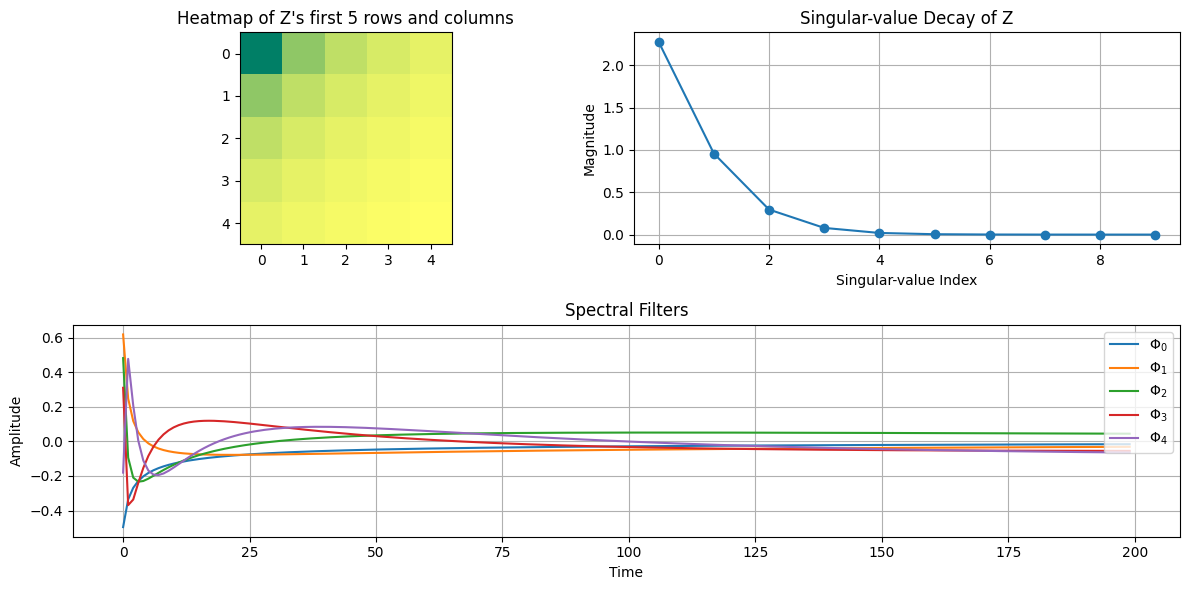

In [8]:
# Standard formulation
# mu_alpha = (alpha - 1)[1, alpha, alpha^2, ...]

Z_std = np.fromfunction(
    z_generator,
    (T, T),
    differential=False,
    dtype=float
)

results_std = spectral_analysis(Z_std)

display_hankel_matrix(
    Z_std,
    results_std["singular_values"],
    results_std["left_singular_vectors"],
    plotting_singular_values=True
)

## 3.3 Comparative Analysis

The experiments presented throughout this section show that the spectral behavior of the Hankel matrix strongly depends on the way the kernel is constructed from the monomial basis.

The differential formulation,

$$
\mu_\alpha
=
(\alpha -1)
[1,\alpha,\alpha^2,\dots]
$$

acts similarly to a discrete differential operator, emphasizing local variations between consecutive monomial terms and reducing the smooth global correlation structure originally present in the basis. As observed experimentally, this operation significantly modifies the spectral geometry of the matrix, producing more localized structures and more oscillatory spectral filters.

In contrast, the non-differential formulation,

$$
\mu_\alpha
=
[1,\alpha,\alpha^2,\dots]
$$

preserves the smooth geometry of the monomial basis and generates a Hankel/Hilbert-like structure with strong global correlations between distant terms. Consequently, the resulting spectral filters become smoother and the matrix energy remains distributed among a larger set of globally correlated modes.

These observations suggest that each formulation may be more appropriate depending on the nature of the problem being analyzed.

The differential formulation may be particularly useful in scenarios where local temporal variations, transient dynamics, abrupt changes, or high-frequency behaviors are relevant. Since the differential operator suppresses smooth components and emphasizes local differences, this formulation may help highlight transitions, anomalies, sharp temporal events, or fast-changing dynamics.

On the other hand, the non-differential Hankel/Hilbert formulation becomes especially attractive for systems dominated by smooth dynamics, persistent temporal correlations, low-frequency behavior, and globally structured trajectories. In such cases, the strong correlation structure of the monomial basis may produce compact spectral representations with smoother and more interpretable spectral filters.

Although the present study considered analytical kernel constructions, several alternative formulations can also be explored depending on the available information and the target application.

For example, the Hankel matrix may be constructed directly from the system outputs:

$$
H_y =
\begin{bmatrix}
y_1 & y_2 & \dots \\
y_2 & y_3 & \dots \\
\vdots & \vdots & \ddots
\end{bmatrix}
$$

allowing the spectral analysis to become directly dependent on the observed dynamics of the system.

Similarly, covariance-based constructions may also be employed, such as:

$$
Z = YY^T
$$

or:

$$
Z = U U^T
$$

where the matrices are built from output trajectories, state trajectories, or input signals. In these cases, the spectral structure becomes directly related to the statistical correlations present in the data.

More generally, alternative kernels may also be designed to emphasize specific dynamical properties, such as oscillatory behavior, long-term dependencies, transient dynamics, or frequency-selective structures. This flexibility allows spectral filtering approaches to be adapted to a wide variety of control, identification, estimation, and signal-processing problems.

Therefore, the choice of the Hankel/kernel formulation should not be viewed as unique or fixed, but rather as a modeling decision capable of significantly altering the resulting spectral geometry, filter smoothness, energy distribution, and numerical properties of the decomposition.

## 3.4 Compute k of spectral filters

## Comparison: Elbow Method vs. Retained Energy Method

After the spectral analysis (SVD) of the target matrix, we obtain the singular values $S$ and the left singular vectors $U$. Choosing the number $k$ of spectral filters – i.e., how many columns of $U$ are used to project the signal – directly affects compression, noise filtering, and the predictive power of the online model.

Two classical criteria are often compared: **the elbow method** and **the retained energy method**.

### 1. Elbow Method

- **Procedure**: Normalize the singular value curve by its first value, draw a straight line from the first to the last point, and find the index that maximizes the perpendicular distance to that line. This index is the "elbow".
- **When it is most favorable**: When the curve has a **well‑defined elbow** – typically an abrupt drop followed by a long tail. In that case, the elbow indicates a natural boundary between signal and noise components.
- **Limitation**: For smooth curves or curves with multiple plateaus, the point of maximum distance may become arbitrary or fall near the endpoints, leading to under‑ or over‑estimation of the rank.

### 2. Retained Energy Method

- **Procedure**: Compute the normalized cumulative energy:
  $$ \text{energy}(k) = \frac{\sum_{i=1}^k S_i^2}{\sum_{i=1}^{n} S_i^2} $$
  Choose the smallest $k$ such that the energy exceeds a predefined threshold (e.g., 90%, 95%, 99%).
- **When it is most favorable**: When **there is no clear elbow** – the curve decays smoothly and monotonically. The energy method allows direct control over how much variance is preserved.
- **Limitation**: The choice of threshold is subjective; very high thresholds (99.999%) may yield $k$ close to the full dimension, nullifying compression.

### Practical Guidance

| Singular value curve characteristic | Recommended method |
|--------------------------------------|--------------------|
| Well‑defined elbow (sharp drop)      | **Elbow**          |
| Smooth decay, no clear elbow         | **Energy (95% or 99%)** |
| Maximum compression required          | **Elbow** (if present) |
| Maximum accuracy required             | **Energy** (conservative threshold) |

90% energy: k = 1
95% energy: k = 1
99% energy: k = 1
99.9% energy: k = 2
99.99% energy: k = 2
99.999% energy: k = 3
Elbow method suggests: k = 4


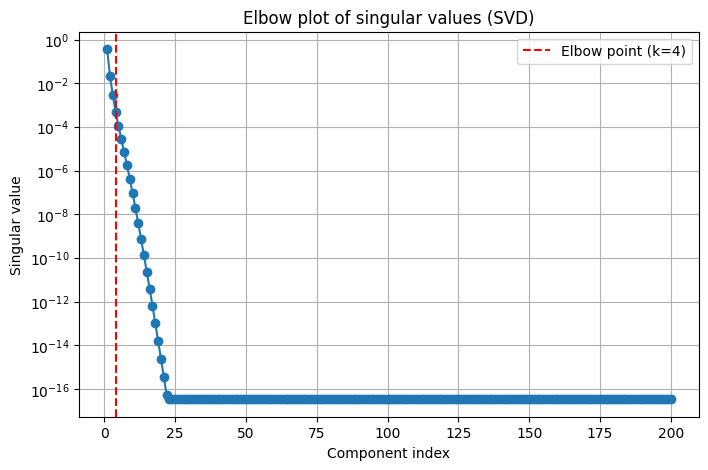

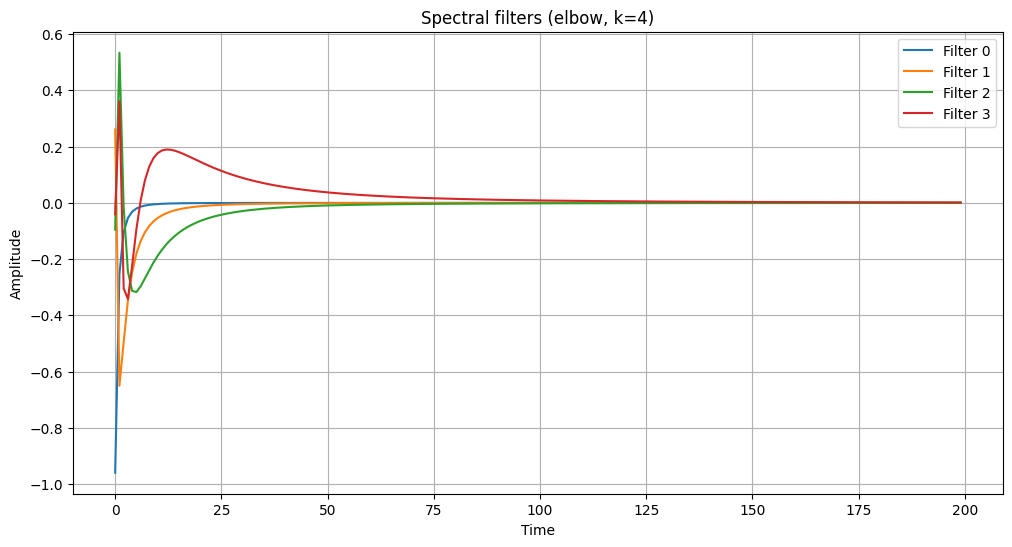

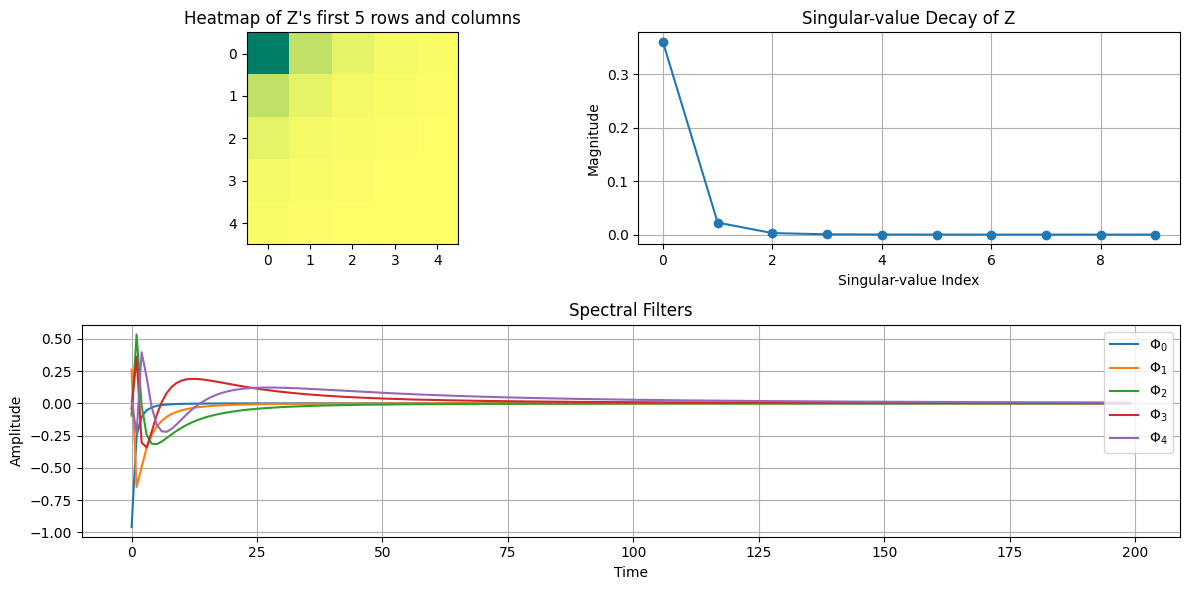

In [9]:

# ============================================================
# Helper function: find elbow point
# ============================================================
def find_elbow_point(S):
    """
    Find the index of the elbow point on the singular value curve
    using the perpendicular distance to the line from first to last point.
    Returns 1-indexed number of components.
    """
    n = len(S)
    y = S / S[0]                     # normalize by the largest singular value
    vec = np.array([n - 1, y[-1] - y[0]])  # vector from first to last point
    distances = []
    for i in range(n):
        p = np.array([i, y[i]])
        t = np.dot(p - np.array([0, y[0]]), vec) / np.dot(vec, vec)
        proj = np.array([0, y[0]]) + t * vec
        dist = np.linalg.norm(p - proj)
        distances.append(dist)
    elbow_idx = np.argmax(distances)
    return elbow_idx + 1   # 1-indexed

# ============================================================
# Energy method
# ============================================================
energy = np.cumsum(S**2) / np.sum(S**2)

thresholds = [0.90, 0.95, 0.99, 0.999, 0.9999, 0.99999]
energy_labels = ['90% energy', '95% energy', '99% energy',
                 '99.9% energy', '99.99% energy', '99.999% energy']

ks_energy = [np.argmax(energy >= thr) + 1 for thr in thresholds]

for label, k in zip(energy_labels, ks_energy):
    print(f'{label}: k = {k}')

# Build the filter sets (first k left singular vectors)
filters_energy = [U[:, :k] for k in ks_energy]

# ============================================================
# Elbow method
# ============================================================
k_elbow = find_elbow_point(S)
print(f'Elbow method suggests: k = {k_elbow}')
filter_elbow = U[:, :k_elbow]

# ============================================================
# Fixed filters for comparison (optional)
# ============================================================
filters_fixed = [U[:, :4], U[:, :16], U[:, :32]]
fixed_labels = ['4 fixed filters', '16 fixed filters', '32 fixed filters']

# ============================================================
# Combine all filters and labels for later comparison
# ============================================================
all_filters = filters_energy + [filter_elbow] + filters_fixed
all_labels = energy_labels + [f'Elbow (k={k_elbow})'] + fixed_labels

# ============================================================
# Plot the elbow curve
# ============================================================
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(S)+1), S, marker='o')
plt.xlabel("Component index")
plt.ylabel("Singular value")
plt.title("Elbow plot of singular values (SVD)")
plt.grid(True)
plt.yscale("log")
plt.axvline(x=k_elbow, color='red', linestyle='--', label=f'Elbow point (k={k_elbow})')
plt.legend()
plt.show()

# ============================================================
# (Optional) Plot the first few spectral filters from the elbow choice
# ============================================================
plt.figure(figsize=(12, 6))
for i in range(min(k_elbow, 10)):
    plt.plot(filter_elbow[:, i], label=f'Filter {i}')
plt.title(f"Spectral filters (elbow, k={k_elbow})")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

# ============================================================
# Visualize the Hankel matrix with its singular values
# ============================================================
display_hankel_matrix(
    Z_diff,
    S,
    U,
    plotting_singular_values=True
)

Later on we will see that for the multidimensional case, the elbow method might not always be the preferred otpions, as the kernels from which the filterbank is extracted may not always be a hankel matrix, see Section 4.3.

# 4. Online Spectral Filtering for Linear Dynamical Systems

After analyzing the spectral geometry of different Hankel kernel formulations, we now apply the resulting spectral filters to the online prediction of Linear Time-Invariant (LTI) systems, defined in section [1.2](#1.2-Linear-Dynamical-Systems).

## 4.1 Filtered Input History Construction

A core concept in spectral filtering and thus the VAW algorithm is the Filtered Input History. 
$$
\vec{u}_{hist}(t) = [\vec{u}_t, \dots , \vec{u}_0, 0, \dots, 0] \in \R^{q\times T}
$$
This representation stores the most recent temporal observations in reversed chronological order while preserving a fixed temporal horizon $T$. Conceptually, the padded history vector acts as a finite-memory approximation of the temporal dynamics of the system. The filtered representation is then obtained by projecting this temporal history onto the spectral basis:

$$
\vec{h}_t
=
\Phi^T
\vec{u}_{hist}(t)
$$

producing a compact feature vector containing the dominant temporal components of the input trajectory.

In [10]:
def build_padded_stack(vecs, n_vec, stack_size):
    n, m = vecs.shape

    out = np.zeros((stack_size, m))

    v_end = np.min([n_vec, n])
    v_start = np.max([0, v_end - stack_size])

    out[0:(v_end-v_start), :] = (vecs[v_start:v_end, :])[::-1]

    return out

## 4.2 Online Spectral Filtering Algorithm

The curvature matrix accumulates second-order information about the spectral features, allowing the algorithm to adaptively rescale the learning process according to the observed temporal structure of the data.

Compared to first-order online learning methods, second-order approaches often produce better numerical conditioning and faster adaptation in problems with correlated features.

---

## 4.3 Generalization to Multidimensional Systems

The current implementation assumes unidimensional input and output $q = r = 1$. For multidimensional systems, the regressor must be generalized to:

$$
\Theta_t
\in
\mathbb{R}^{h\times r}
$$

allowing multiple outputs to be predicted simultaneously. Similarly, the filtered feature construction may be extended to incorporate:

- multidimensional inputs;
- output histories;
- state trajectories;
- covariance-based features;
- and alternative spectral kernels.

These extensions allow the spectral filtering framework to be applied to a broader class of control, identification, estimation, and sequential prediction problems.

The following implementation reproduces the original Spectral Filtering with VAW procedure presented as Algorithm 8 in [*Introduction to Online Control* (version 1.2 β)](#Reference-Algorithm) by Elad Hazan and Karan Singh.

In [11]:
def online_spectral_filtering(A, B, C, filters, eps_curvature = 1e-3):
    T, h = filters.shape

    curvature = eps_curvature * np.eye(h)
    regressor = np.zeros((T, h))
    
    n, m = A.shape
    _, q = B.shape
    r, _ = C.shape

    x = np.zeros((T + 1, n))
    u = np.random.randn(T, q) * 0.5
    y = np.zeros((T, r))
    y_hat = np.zeros((T, r))

    for t in range(T):
        #apply control
        x[t + 1] = A @ x[t] + B @ u[t]

        #opponent applies noise
        x[t + 1] += 0.05 * np.random.randn(1)

        #filter input history
        u_history = build_padded_stack(u, t, T) 
        h_t = filters.T @ u_history

        #curvature update
        curvature = curvature + h_t @ h_t.T
        
        #predict output y_hat
        y_hat[t] = h_t.T @ np.linalg.inv(curvature) @ regressor[t-1] #CAREFUL: v[t-1] for first iter will return last, element. This works only 'cuz initialized at zero
        
        #reveal real output y_t
        y[t] = C @ x[t]
        
        #update the regressor
        regressor[t] = regressor[t-1] + y[t] * h_t.flatten()
    return x, u, y, y_hat


Although the original formulation captures the core spectral filtering mechanism, the direct implementation above presents several numerical and structural issues.

First, the original algorithm updates the curvature matrix before generating the prediction. This introduces information leakage because the current feature vector is incorporated into the geometry of the predictor prior to prediction. In the corrected implementation below, prediction is performed before the curvature update.$

Second, the direct implementation requires explicit inversion of the curvature matrix at every iteration:

$$
A_t^{-1}
$$

which is numerically unstable and computationally inefficient. The revised implementation replaces explicit inversion with numerically stable linear solves and later extends the method further using Sherman–Morrison inverse updates.

Additionally, the original scalar formulation assumes:

$$
u_t \in \mathbb{R},
\qquad
y_t \in \mathbb{R}
$$

which implicitly restricts the algorithm to single-input single-output systems. The implementation developed below first corrects the scalar implementation and later generalizes the method to multidimensional MIMO systems by vectorizing the filtered representations and extending the regression geometry to matrix-valued predictors.

In [12]:
def online_spectral_filtering(A, B, C, filters, eps_curvature=1e-3, eps_regressor=1e-3):
    """
    Filters:
        [phi_1 ... phi_h]
        with phi_i \\in R^T

    filters.shape = (T, h)
    """

    T, h = filters.shape

    curvature = eps_curvature * np.eye(h)
    regressor = eps_regressor * np.ones(h)

    n, _ = A.shape
    _, q = B.shape
    r, _ = C.shape

    x = np.zeros((T + 1, n))
    u = np.random.randn(T, q) * 0.5
    y = np.zeros((T, r))
    y_hat = np.zeros((T, r))
    cumulative_loss = np.zeros(T)  

    for t in range(T):
        x[t + 1] = A @ x[t] + B @ u[t]
        x[t + 1] += 0.05 * np.random.randn(n)

        u_history = build_padded_stack(u, t, T)

        h_t = filters.T @ u_history
        h_t = h_t.flatten()

        y_hat[t] = (h_t.T @ np.linalg.solve(curvature, regressor))
        y[t] = C @ x[t]

        #TODO(jtu): return regret instead of pring and plot + compare to y=x line to see if sublinear
        #Cumulative loss 
        error = y[t] - y_hat[t]
        loss = np.linalg.norm(error) ** 2

        cumulative_loss[t] = cumulative_loss[t-1] + loss if t > 0 else loss

        print("Cumulative loss array:")
        print(cumulative_loss)
        print(f"Total cumulative loss: {cumulative_loss[-1]}")

        curvature += np.outer(h_t, h_t) 

        regressor += y[t].flatten() * h_t 

    return x, u, y, y_hat

In [13]:
def plot_online_spectral_filtering_comparison(A, B, C, filters_list, labels=None, eps_curvature=1e-3, eps_regressor=1e-3, seed=0):
    """
    Compare multiple spectral filter configurations on the SAME trajectory.

    Parameters
    ----------
    A, B, C : ndarray
        LTI system matrices.

    filters_list : list[np.ndarray]
        List of spectral filter matrices of shape (T, h).

    labels : list[str]
        Labels associated with each filter configuration.

    eps_curvature : float
        Curvature regularization parameter.

    eps_regressor : float
        Regressor initialization parameter.

    seed : int
        Random seed for reproducibility.

    Returns
    -------
    results : list[dict]
        Experiment results for each filter configuration.
    """

    np.random.seed(seed)

    n, _ = A.shape
    _, q = B.shape
    r, _ = C.shape

    T = filters_list[0].shape[0]

    for F in filters_list:
        assert F.shape[0] == T, "All filter banks must share the same temporal horizon T."


    if labels is None:
        labels = [f"{F.shape[1]} spectral filters" for F in filters_list]

    u = np.random.randn(T, q) * 0.5
    process_noise = 0.05 * np.random.randn(T, n)

    x_ref = np.zeros((T + 1, n))
    y_ref = np.zeros((T, r))

    for t in range(T):
        x_ref[t + 1] = A @ x_ref[t] + B @ u[t] + process_noise[t]
        y_ref[t] = C @ x_ref[t]

    results = []

    for filters, label in zip(filters_list, labels):
        h = filters.shape[1]

        curvature = eps_curvature * np.eye(h)
        regressor = np.ones(h) * eps_regressor

        y_hat = np.zeros((T, r))

        prediction_error = np.zeros((T, r))

        for t in range(T): #TODO(jtu): use the online_spectral_filtering here(?), maybe needs to be adapted, but we define here the exact same steps as in the function!
            u_history = build_padded_stack(u, t, T)

            h_t = filters.T @ u_history
            h_t = h_t.flatten()

            y_hat[t] = h_t.T @ np.linalg.solve(curvature, regressor)

            y_t = y_ref[t]

            prediction_error[t] = y_t - y_hat[t]

            curvature += np.outer(h_t, h_t)
            regressor += y_t.flatten() * h_t


        mse = np.mean(np.linalg.norm(prediction_error, axis=1) ** 2)
        rmse = np.sqrt(mse)


        results.append(
            {
                "label": label,
                "u": u,
                "y": y_ref,
                "y_hat": y_hat,
                "error": prediction_error,
                "mse": mse,
                "rmse": rmse,
                "r2": 1 - mse / np.var(y_ref),
                "curvature_condition": np.linalg.cond(curvature),
            }
        )

    #TODO(jtu): TBD I would split this function here, once in a simulation function and once in a plotting function
    fig, axes = plt.subplots(len(results), 1, figsize=(12, 4 * len(results)), sharex=True,)

    if len(results) == 1: axes = [axes]

    for ax, result in zip(axes, results):
        y = result["y"][:, 0]
        y_hat = result["y_hat"][:, 0]

        ax.plot(y, label="true output $y_t$")
        ax.plot(y_hat, "--", label="prediction $\\hat y_t$")

        ax.set_title(
            (
                f"{result['label']} | "
                f"MSE = {result['mse']:.6f} | "
                f"RMSE = {result['rmse']:.6f} | "
                f"R2 = {result['r2']:.6f}"
            )
        )

        ax.set_ylabel("output")
        ax.grid(True)
        ax.legend()

    axes[-1].set_xlabel("time")

    plt.tight_layout()
    plt.show()

    return results

## 4.4 Experimental Comparison of Spectral Filters

The following experiment evaluates how the number of retained spectral filters affects the online prediction performance of the spectral filtering framework.

The spectral filters are extracted from the dominant left singular vectors of the Hankel matrix decomposition:

$$
Z
=
U\Sigma V^T
$$

where the columns of:

$$
U
=
[\phi_1,\phi_2,\dots,\phi_h]
$$

define the spectral basis used to represent the temporal dynamics of the system.

Different numbers of filters correspond to different low-rank approximations of the temporal structure encoded in the Hankel matrix. Smaller filter banks produce compact spectral representations, while larger filter banks preserve a larger portion of the spectral geometry of the system.

The experiment compares three different spectral dimensionalities:

- 4 spectral filters;
- 16 spectral filters;
- 32 spectral filters.

All experiments are performed using the same input trajectory and the same noise realization in order to ensure a fair comparison between the different spectral bases.

The objective is to analyze how the spectral dimensionality affects:

- prediction accuracy;
- temporal reconstruction quality;
- smoothness of the predictions;
- and the ability of the online learner to capture the system dynamics.

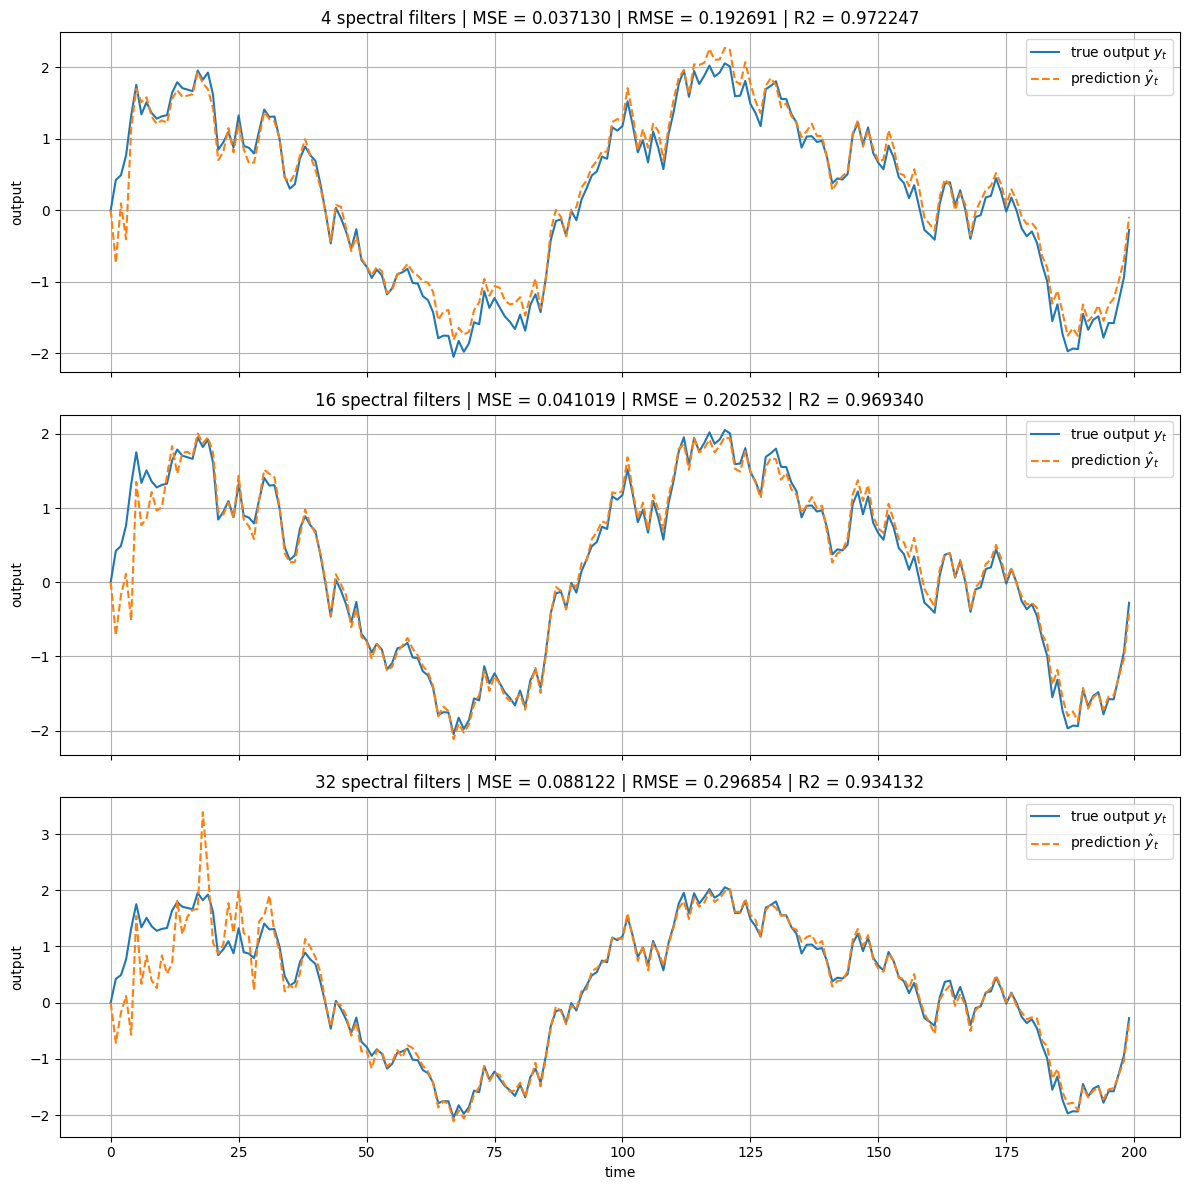

In [14]:
filters_4 = U[:, :4]
filters_16 = U[:, :16]
filters_32 = U[:, :32]

results = plot_online_spectral_filtering_comparison(
    A=A,
    B=B,
    C=C,
    filters_list=[
        filters_4,
        filters_16,
        filters_32,
    ],
    labels=[
        "4 spectral filters",
        "16 spectral filters",
        "32 spectral filters",
    ],
    eps_curvature=1e-3,
    eps_regressor=1e-3,
    seed=0,
)

## 4.5 Analysis of the Experimental Results

The experimental results reveal that the prediction quality strongly depends on the number of retained spectral filters.

With only 4 spectral filters, the algorithm is already capable of capturing the dominant low-frequency structure of the system, producing accurate predictions with relatively low reconstruction complexity.

Increasing the number of filters to 16 slightly improves the prediction performance, indicating that additional spectral modes contribute useful temporal information to the online learner. In this case, the spectral basis achieves a better balance between compactness and representational capacity, leading to the lowest observed prediction error.

However, increasing the number of filters to 32 produces a noticeable degradation in performance, resulting in larger prediction errors and noisier trajectory estimation.

This behavior is expected in spectral filtering methods. The dominant singular vectors usually capture the most relevant smooth temporal structures of the system, while higher-order spectral modes tend to represent smaller residual variations, noisy components, or highly oscillatory dynamics.

Consequently, including too many spectral filters may increase the dimensionality of the online learning problem without necessarily improving the quality of the temporal representation. In some cases, excessive spectral dimensionality may even deteriorate numerical conditioning and amplify noisy components of the dynamics.

From a geometric perspective, the experiment highlights the connection between spectral filtering and low-rank approximation methods such as Principal Component Analysis (PCA) and truncated Singular Value Decomposition (SVD), where a small subset of dominant spectral modes concentrates most of the relevant system energy.

These results suggest that the best online prediction performance is often achieved using a compact low-rank spectral representation rather than the full spectral basis.

## 5. Online Spectral Filtering for Multidimensional Dynamical Systems

Consider now the LDS system presented in section [1.2](#1.2-Linear-Dynamical-Systems) with multiple inputs and outputs.


In [15]:
# Stable coupled system
A = np.array([
    [0.92, 0.05, 0.00, 0.00],
    [0.00, 0.88, 0.04, 0.00],
    [0.00, 0.00, 0.90, 0.03],
    [0.02, 0.00, 0.00, 0.85],
])

B = np.array([
    [1.0, 0.0],
    [0.0, 1.0],
    [0.5, 0.2],
    [0.1, 0.8],
])

C = np.array([
    [1.0, 0.0, 0.5, 0.0],
    [0.0, 1.0, 0.0, 0.5],
])


### Delayed Input Embedding

At time $t$, define the causal input history as $\tilde u_t=[u_{t-1},u_{t-2},\dots,u_1,0,\dots,0]^\top$. Then for multidimensional inputs, it becomes $u_t \in \mathbb{R}^q$:

the delayed history becomes then a matrix

$$
\tilde U_t \in \mathbb{R}^{T\times q}
$$

whose rows contain time-shifted input vectors. Projection onto the spectral basis yields the filtered representation

$$
H_t = \Phi_h^\top \tilde U_t
$$

with $H_t \in \mathbb{R}^{h\times q}$. Each row corresponds to a spectral filter, while each column corresponds to an input channel. To obtain a standard linear regression formulation, the filtered representation is vectorized as follows:

$$
h_t = \mathrm{vec}(H_t) \in \mathbb{R}^{hq}
$$

Thus, the online prediction problem becomes linear in the spectral feature space.


### Online Ridge Regression Formulation

The predictor is now modeled as $\hat y_t = \Theta_t^\top h_t $ where $\Theta_t \in \mathbb{R}^{hq\times r}$ is the matrix of regression coefficients. The online learner minimizes the regularized cumulative loss

$$
\sum_{\tau=1}^{t} \|y_\tau-\Theta^\top h_\tau\|^2 + \lambda\|\Theta\|_F^2
$$

This yields the closed-form minimizer $\Theta_t = A_t^{-1}V_t$ with curvature matrix

$$
A_t = \lambda I + \sum_{\tau=1}^{t} h_\tau h_\tau^\top
$$

and sufficient statistics

$$
V_t = \sum_{\tau=1}^{t} h_\tau y_\tau^\top
$$

The prediction finally becomes $\hat y_t = h_t^\top A_t^{-1}V_t$

### Curvature Geometry

The matrix $A_t$ acts as a second-order geometric descriptor of the observed feature space. It accumulates directional correlations of the spectral features and defines the adaptive metric

$$
\|x\|_{A_t}^2 = x^\top A_t x
$$

One may workw with the inverse matrix be denoted here as $P_t = A_t^{-1}$, which quantifies how aggressively the predictor adapts along each direction of the feature space. Indeed, directions with large accumulated curvature become increasingly resistant to parameter variation, while poorly observed directions retain larger uncertainty and freedom of adaption. 

### Sherman-Morrison Inverse Updates

Direct inversion of the curvature matrix at every iteration is computationally expensive. Knowing that the curvature evolves through rank-one updates, we can exploit the Sherman–Morrison identity. Indeed for an update as follows

$$
A_t = A_{t-1} + h_t h_t^\top
$$

its inverse can be updated recursively using the Sherman–Morrison identity:

$$
P_t = P_{t-1} - \frac{P_{t-1}h_th_t^\top P_{t-1} }{1+h_t^\top P_{t-1}h_t }
$$

We can conceptually decompose the update of the inverse into two components, where the scalar $1+h_t^\top P_{t-1}h_t$ measures the effective curvature along the incoming feature direction, while $$p_t p_t^\top$ defines the corresponding directional curvature correction, for

$$
p_t = P_{t-1}h_t
$$

The update becomes:

$$
P_t = P_{t-1} - \frac{p_t p_t^\top}{1+h_t^\top p_t}
$$

This update improves the computational load of the algorithm by avoiding repeaded matrix inversions, preserving the second-order geometry.

### Multidimensional Extension

The original scalar-output formulation proposed by the authors of the book assumes $u_t \in \mathbb{R}$ and $y_t \in \mathbb{R}$, with $h_t \in \mathbb{R}h$ and $v_t \in \mathbb{R}^h$. For multidimensional systems, this can be extended with the following considerations: Given

$$
u_t \in \mathbb{R}^q, \qquad y_t \in \mathbb{R}^r
$$

the filtered representation, as seen above, becomes matrix-valued: $H_t \in \mathbb{R}^{h\times q}$, however, to recover a standard linear predictor, the filtered matrix is vectorized, yielding $h_t \in \mathbb{R}^{hq}$. Consequently, the regression target becomes matrix-valued as well: $V_t \in\mathbb{R}^{hq\times r}$ and the predictor becomes 
$$
\Theta_t = P_tV_t \in\mathbb{R}^{hq\times r}
$$

Now, the prediction equation generalizes naturally to

$$
\hat y_t = h_t^\top P_tV_t
$$

This preserves the original VAW structure while extending the algorithm to MIMO systems.

---

### Geometric Interpretation of the Multidimensional Extension

Each spectral filter acts simultaneously on every input channel. Vectorization converts the tensor-product structure $\text{filters} \times \text{channels}$ into a single feature space of dimension $h\cdot q$. The online learner therefore operates over coupled spatiotemporal coordinates:

- temporal structure is encoded by the spectral filters,
- channel interactions are encoded by the regression matrix,
- second-order adaptation is controlled through the inverse curvature geometry.

The resulting algorithm may be interpreted as an online second-order learning method operating over compressed dynamical trajectory coordinates.

In [16]:
def online_spectral_filtering_multi(A, B, C, filters, eps_curvature=1e-3, eps_regressor=0.0):
    """
    Filters:
        [phi_1 ... phi_h]
        with phi_i \\in R^T

    filters.shape = (T, h)
    """

    T, h = filters.shape

    n, _ = A.shape
    _, q = B.shape
    r, _ = C.shape

    inverse_curvature = (1 / eps_curvature) * np.eye(h * q)
    regressor = eps_regressor * np.ones((h * q, r))

    x = np.zeros((T + 1, n))
    u = np.random.randn(T, q) * 0.5
    y = np.zeros((T, r))
    y_hat = np.zeros((T, r))
    r = np.zeros(T+1)

    for t in range(T):
        #apply control
        x[t + 1] = A @ x[t] + B @ u[t]
        
        #opponent applies noise
        x[t + 1] += 0.05 * np.random.randn(n)
        
        #filter input history
        u_history = build_padded_stack(u, t, T)
        
        h_t = (filters.T @ u_history).reshape(-1)
        
        y_hat[t] = h_t.T @ inverse_curvature @ regressor
        
        #reveal real output y_t
        y[t] = C @ x[t]

        #accumulate regret
        r[t+1] = r[t] + np.linalg.norm(y[t] - y_hat[t], 2)**2

        #Sherman–Morrison update of inverse curvature
        Ph = inverse_curvature @ h_t
        curvature_correction = np.outer(Ph, Ph)
        innovation_variance = 1 + h_t @ Ph

        inverse_curvature -= curvature_correction / innovation_variance

        #update the regressor
        regressor += np.outer(h_t, y[t])

    return x, u, y, y_hat, r


To evaluate the spectral filtering procedure, we first need operators whose dominant spectral modes will generate the temporal filters.

## 5.1. Finite-Horizon Observability–Controllability Operator

This construction explicitly encodes the input-output dynamics of the system. For horizon $T$, let the controllability matrix be defined as follows, given the dynamical system's matrices $A$, $B$ and $C$: 
$$
\mathcal C_T
=
\begin{bmatrix}
B & AB & A^2B & \cdots & A^{T-1}B
\end{bmatrix}
$$

with shape $\mathcal C_T \in \mathbb{R}^{n\times qT}$. This matrix spans the reachable state subspace generated by the inputs. Similarly, the observability matrix can be defined:
$$
\mathcal O_T
=
\begin{bmatrix}
C \\
CA \\
CA^2 \\
\vdots \\
CA^{T-1}
\end{bmatrix}
$$

with shape $\mathcal O_T \in \mathbb{R}^{rT\times n}$. This matrix encodes how latent states become observable through time.

### Input-Output Hankel Operator

The finite-horizon input-output operator is then derived as follows: $\mathcal H_T = \mathcal O_T \mathcal C_T$, with shape $\mathcal H_T \in \mathbb{R}^{rT\times qT}$. Explicitly, we have:

$$
\mathcal H_T
=
\begin{bmatrix}
CB & CAB & CA^2B & \cdots \\
CAB & CA^2B & CA^3B & \cdots \\
CA^2B & CA^3B & CA^4B & \cdots \\
\vdots & \vdots & \vdots &
\end{bmatrix}
$$

This is a block-Hankel matrix of Markov parameters. Its dominant singular vectors capture:
- controllable modes,
- observable modes,
- dominant input-output dynamics.

These singular vectors are natural candidates for spectral filters

In [17]:
def controllability_matrix(A, B, T):
    blocks = [np.linalg.matrix_power(A, k) @ B for k in range(T)]

    return np.hstack(blocks)


def observability_matrix(A, C, T):
    blocks = [C @ np.linalg.matrix_power(A, k) for k in range(T)]

    return np.vstack(blocks)


def hankel_operator(A, B, C, T):
    O = observability_matrix(A, C, T)
    Ctrb = controllability_matrix(A, B, T)

    return O @ Ctrb

## 5.2. Output Auto-Correlation Operator

Instead of explicitly using system matrices, one may estimate temporal structure directly from trajectories. Suppose an output trajectory

$$
Y
=
\begin{bmatrix}
| & | & & | \\
y_1 & y_2 & \cdots & y_T \\
| & | & & |
\end{bmatrix}
\in
\mathbb{R}^{r\times T}
$$

Then the empirical output covariance is

$$
H_{YY}
=
YY^\top
$$

with shape $R_Y \in \mathbb{R}^{r\times r}$. This captures dominant variance directions in output space. Here it is important to note that, unlike Hankel embeddings, this operator does **not** explicitly encode temporal ordering. Instead, it captures:
- spatial covariance,
- dominant energetic modes,
- channel correlations,

but not dynamical transition structure. Still, its leading eigenvectors often recover useful low-dimensional structure.

In [18]:
def output_autocorrelation(Y):
    return Y @ Y.T

## 5.3. Skewed-Diagonal Temporal Operator

A third possibility is constructing a structured temporal operator directly from lag interactions. Given a scalar sequence $s_1,\dots,s_T$ a skewed-diagonal operator places values along anti-diagonals:
$$
S
=
\begin{bmatrix}
s_1 & s_2 & s_3 & \cdots \\
s_2 & s_3 & s_4 & \cdots \\
s_3 & s_4 & s_5 & \cdots \\
\vdots & \vdots & \vdots &
\end{bmatrix}
$$

This is structurally equivalent to a Hankel matrix. For multidimensional outputs, one may:
- build separate operators per channel,
- average across channels,
- or construct block-Hankel embeddings.

The advantage of such operators, over the previous example of $\mathcal H_T$ is that the system's dynamics can be unknown. Further more, if compared to $\Chi_Y$ we can say that it encodes:
- lag correlations,
- oscillatory structure,
- temporal persistence,
- delayed dependencies.

The dominant spectral modes extracted from these operators frequently yield effective temporal filters.

In [19]:
def skewed_diagonal_1D(signal, T):
    """Hankel / skewed-diagonal operator for 1D signals."""
    H = np.zeros((T, T))

    for i in range(T):
        for j in range(T):
            idx = i + j

            if idx < len(signal):
                H[i, j] = signal[idx]

    return H

def skewed_diagonal_mimo(signal, T):
    """
    Block-Hankel / skewed-diagonal operator for MIMO signals.

    Parameters
    ----------
    signal : ndarray, shape (N, r)
        Multidimensional signal trajectory.

    T : int
        Temporal horizon.

    Returns
    -------
    H : ndarray, shape (T*r, T*r)
        Block skewed-diagonal operator.
    """

    N, r = signal.shape

    H = np.zeros((T * r, T * r))

    for i in range(T):
        for j in range(T):

            idx = i + j

            if idx < N:

                y = signal[idx].reshape(-1, 1)
                block = y @ y.T

                row_slice = slice(i * r, (i + 1) * r)
                col_slice = slice(j * r, (j + 1) * r)

                H[row_slice, col_slice] = block

    return H

### Spectral Extraction

Once any of these operators is constructed, filters are obtained through eigendecomposition or singular value decomposition, as for the unidimensional case with $Z_T$. The resulting filters define the low-dimensional spectral basis used by the online predictor.

### Interpretation of the Three Operators

| Operator | Encodes |
|---|---|
| $\mathcal H_T$ | exact input-output dynamics |
| $H_{YY}$ | output covariance / energetic modes |
| $H_{\text{skew}}$ | temporal lag structure |

These constructions correspond to progressively weaker assumptions about knowledge of the underlying system:
- full model-based dynamics,
- trajectory statistics,
- purely temporal structure.

## 6. Testing the MIMO Algorithm

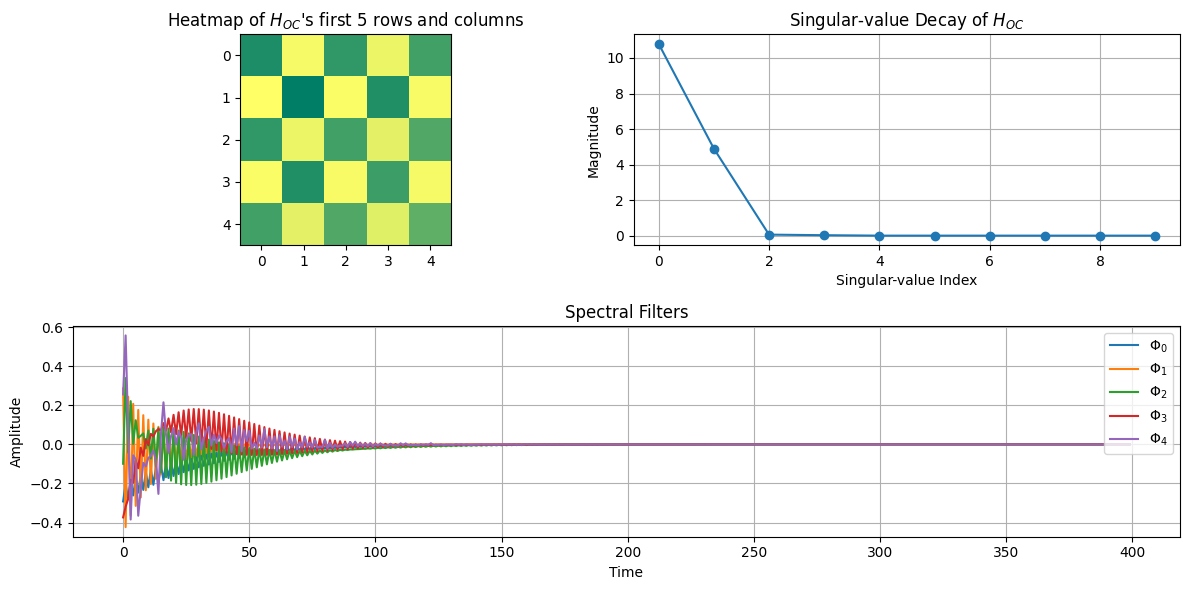

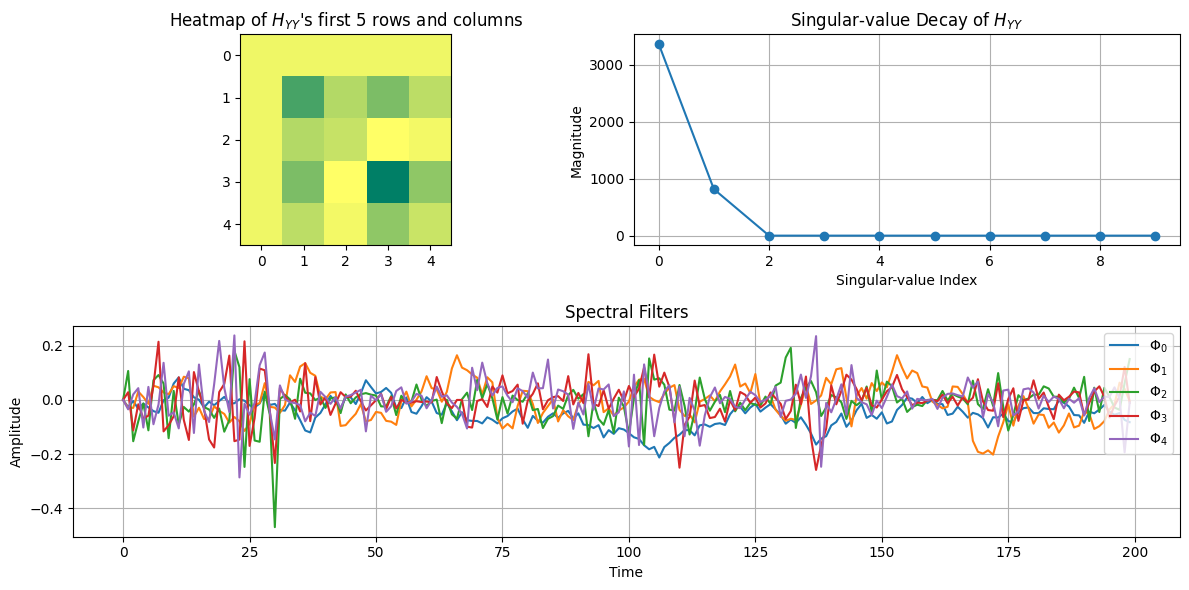

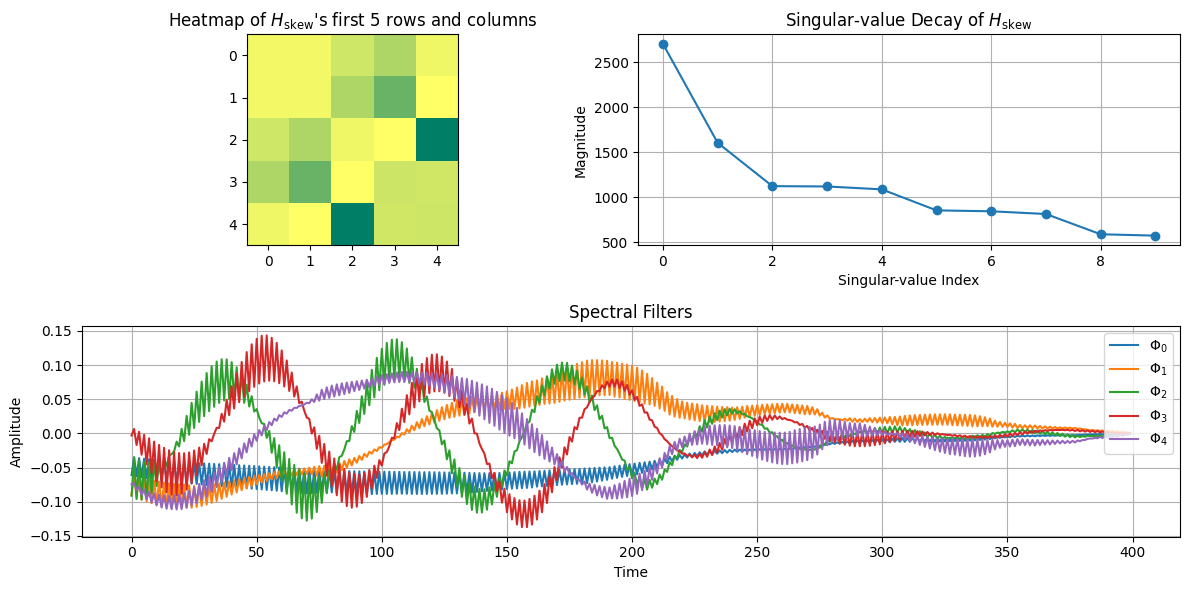

In [20]:
x, u, y = rollout(A, B, C, T=T, noise_std=0.05)

H_oc = hankel_operator(A, B, C, T)
H_yy = output_autocorrelation(y)
H_sk = skewed_diagonal_mimo(y, T)

# get filter banks
filters_oc = spectral_analysis(H_oc)
filters_yy = spectral_analysis(H_yy)
filters_sk = spectral_analysis(H_sk)

display_hankel_matrix(H_oc, filters_oc["singular_values"], filters_oc["left_singular_vectors"], plotting_singular_values=True, mat_name="$H_{OC}$")
display_hankel_matrix(H_yy, filters_yy["singular_values"], filters_yy["left_singular_vectors"], plotting_singular_values=True, mat_name="$H_{YY}$")
display_hankel_matrix(H_sk, filters_sk["singular_values"], filters_sk["left_singular_vectors"], plotting_singular_values=True, mat_name="$H_{\\text{skew}}$")


In [21]:
def evaluate_filterbanks(A, B, C, filterbanks, num_filters=None, eps_curvature=1e-3, eps_regressor=0.0, ):
    """
    Apply online spectral filtering to multiple filterbanks.

    Parameters
    ----------
    filterbanks : list[np.ndarray]

        Each filterbank has shape:

            (T, h_max)

    num_filters : int | None

        Number of filters to retain from each bank.
        If None, all filters are used.

    Returns
    -------
    results : list[dict]

        One result dictionary per filterbank.
    """

    results = []

    for filters in filterbanks:

        if num_filters is not None:
            filters = filters[:, :num_filters]

        x, u, y, y_hat, r = online_spectral_filtering_multi(A, B, C, filters, eps_curvature=eps_curvature, eps_regressor=eps_regressor, )

        mse = np.mean((y - y_hat) ** 2)

        results.append({
            "filters": filters,
            "x": x,
            "u": u,
            "y": y,
            "y_hat": y_hat,
            "mse": mse,
            "regret": r
        })

    return results

def plot_filterbank_results(results, names=None, output_dim=0, output_range=None, ):
    """
    Compare true vs predicted outputs for each filterbank.

    Parameters
    ----------
    results : list[dict]

    names : list[str] | None

        Optional names for each filterbank.

    output_dim : int

        Used when output_range is None.

    output_range : tuple | None

        (start, end, step)

        Example:
            (0, 100, 5)

        plots:
            0, 5, 10, ...
    """

    if names is None:
        names = [f"filterbank_{i}" for i in range(len(results))]

    n_results = len(results)

    if output_range is None:
        indices = [output_dim]
    else:
        start, end, step = output_range
        indices = list(range(start, end, step))

    n_outputs = len(indices)

    fig, axes = plt.subplots( n_results, n_outputs + 1, figsize=(5 * (n_outputs + 1), 3 * n_results), squeeze=False, )

    for row, (result, name) in enumerate(zip(results, names)):

        mse = result["mse"]

        for col, idx in enumerate(indices):

            ax = axes[row, col]

            y = result["y"][:, idx]
            y_hat = result["y_hat"][:, idx]

            ax.plot(y, label="y")
            ax.plot(y_hat, label="y_hat")

            ax.set_title(f"{name}\noutput={idx} | MSE={mse:.6f}")

            ax.set_xlabel("time step")
            ax.set_ylabel("value")

            ax.legend()

        # plot regret in last
        ax = axes[row, -1]
        
        regret = result["regret"]
        x = np.arange(len(regret))
        
        ax.plot(regret, label="regret")
        ax.plot(x, x, linestyle="--", label="y=x")
        
        ax.set_title(f"{name}\nregret")
        
        ax.legend()

    plt.tight_layout()
    plt.show()

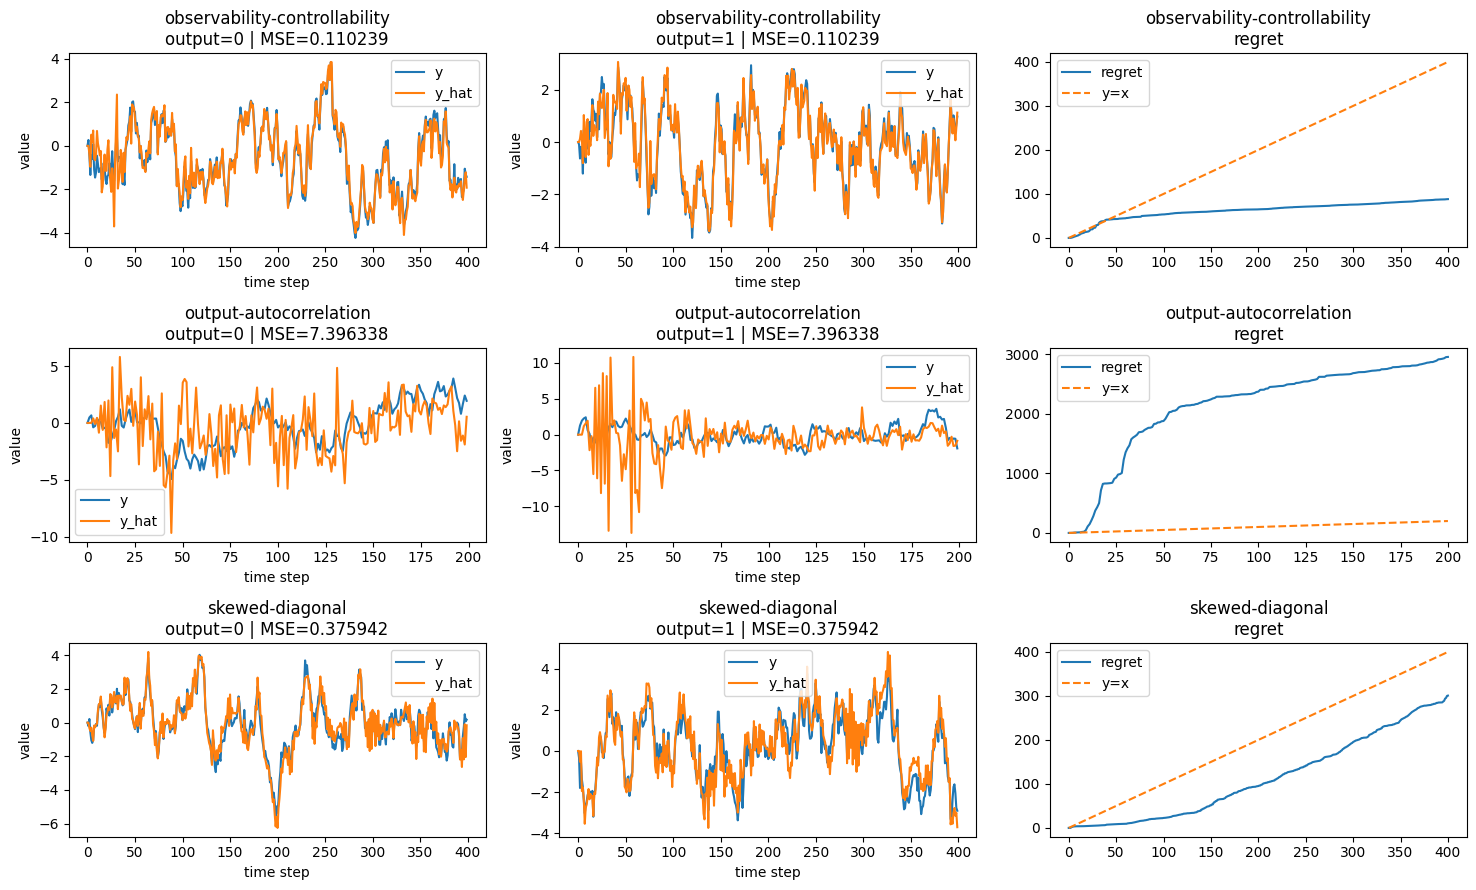

In [22]:
filterbanks = [
    filters_oc["left_singular_vectors"],
    filters_yy["left_singular_vectors"],
    filters_sk["left_singular_vectors"],
]

names = [
    "observability-controllability",
    "output-autocorrelation",
    "skewed-diagonal",
]

results = evaluate_filterbanks(A, B, C, filterbanks, num_filters=16, )

plot_filterbank_results(results, names=names, output_range=(0, 2, 1))
